# Customer Churn Prediction and Retention Recommendation System

## Project Overview

This project uses machine learning to predict whether a telecom
customer is likely to churn.

### Machine Learning Models
- Logistic Regression
- Random Forest
- XGBoost

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

### Dataset
Telco Customer Churn Dataset

In [1]:
#installing required libraries
!pip install -q xgboost openpyxl joblib

In [2]:
# Importing the libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Loading the Excel file
file_path = "/content/Telco_customer_churn.xlsx"

df = pd.read_excel(file_path)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
# Understanding the dataset
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [7]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [8]:
# Checking if there are any missing values in the dataset
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [9]:
#Understanding the target variable which is churn label

df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


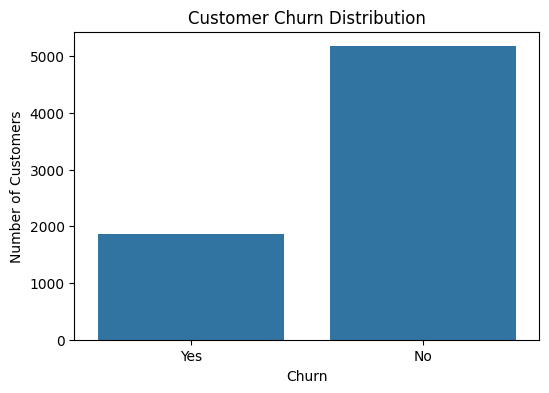

In [10]:
# Visualizing the target variable

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
# Calculating the churn percentage and rate
churn_percentage = (
    df["Churn Label"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percentage)

churn_rate = (
    df["Churn Value"].mean() * 100
)

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
Overall Churn Rate: 26.54%


In [12]:
# Data Cleaning
# Currently our data is stored as objects or string value so we need convert it into numberic value
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [13]:
# Now again we need to check if there are any missing values present or not
df["Total Charges"].isnull().sum()

np.int64(11)

In [14]:
# We got the Missing values lets drop them
df = df.dropna(
    subset=["Total Charges"]
)

In [15]:
df["Total Charges"].isnull().sum()

np.int64(0)

In [16]:
df.shape

(7032, 33)

In [17]:
# For our project there are some unnecessary columns that we don't need for prediction
# So we will simply remove them

columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

df_model = df.drop(
    columns=columns_to_drop
)

In [18]:
# Checking the remaining columns
df_model.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'],
      dtype='object')

In [19]:
# Now lets check the numerical Features
df_model.describe()

,Tenure Months,Monthly Charges,Total Charges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


## Exploratory Data Analysis

### Churn by Contract Type

Contract duration may influence customer retention.

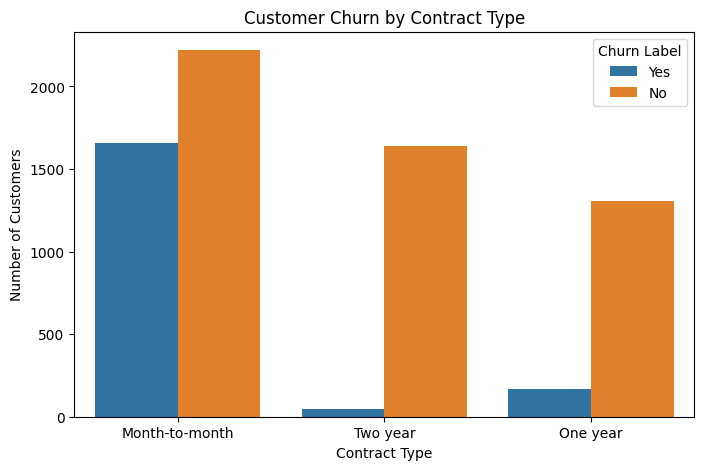

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Contract",
    hue="Churn Label"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

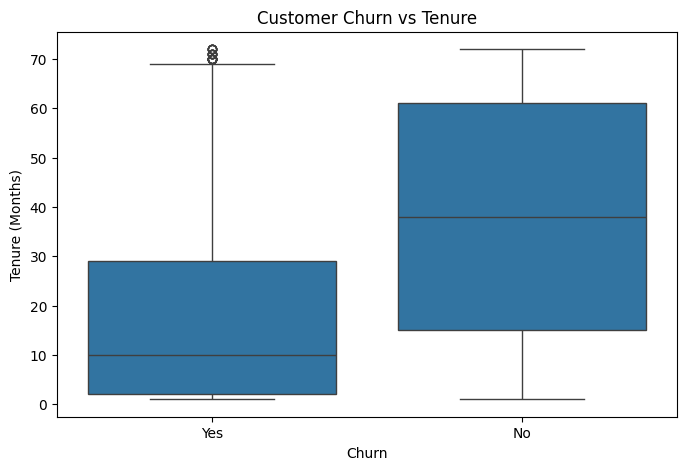

In [21]:
# Churn vs Tenure
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_model,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Customer Churn vs Tenure")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

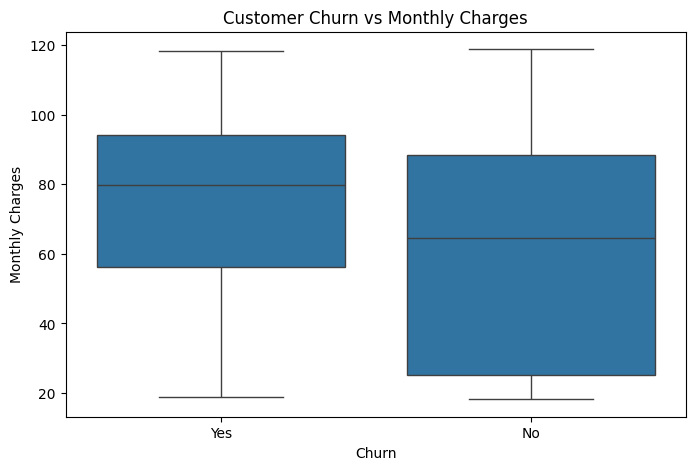

In [22]:
# Churn vs Monthly Charges
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_model,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Customer Churn vs Monthly Charges")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

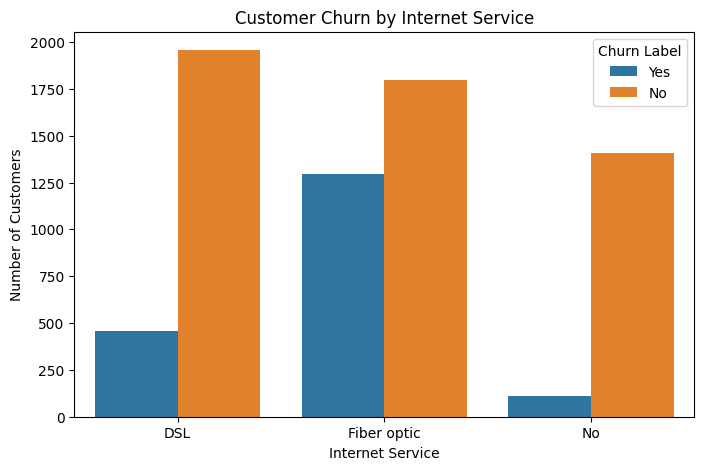

In [23]:
# Churn vs Internet service
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

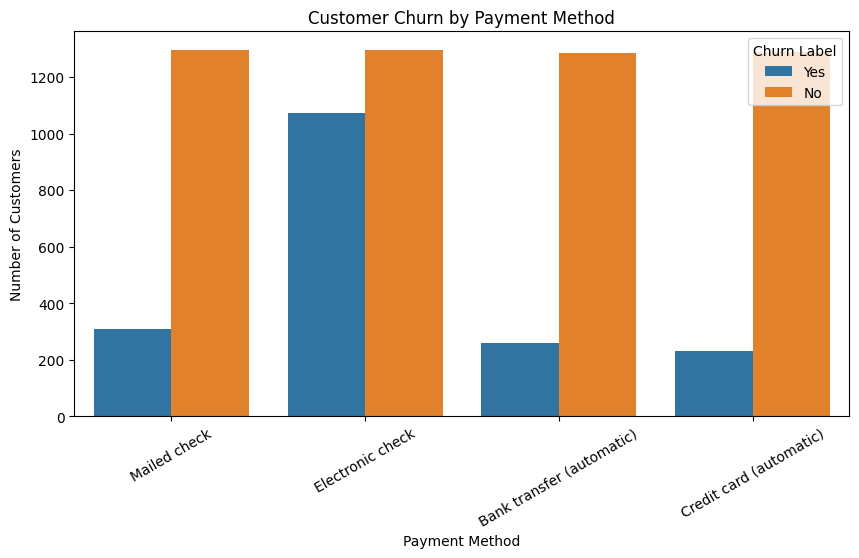

In [24]:
# Churn vs Payment method
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_model,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

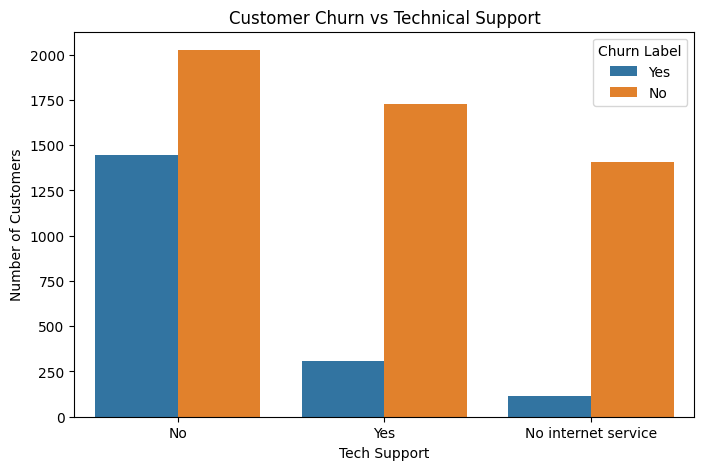

In [25]:
# Churn vs Tech support
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Tech Support",
    hue="Churn Label"
)

plt.title("Customer Churn vs Technical Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

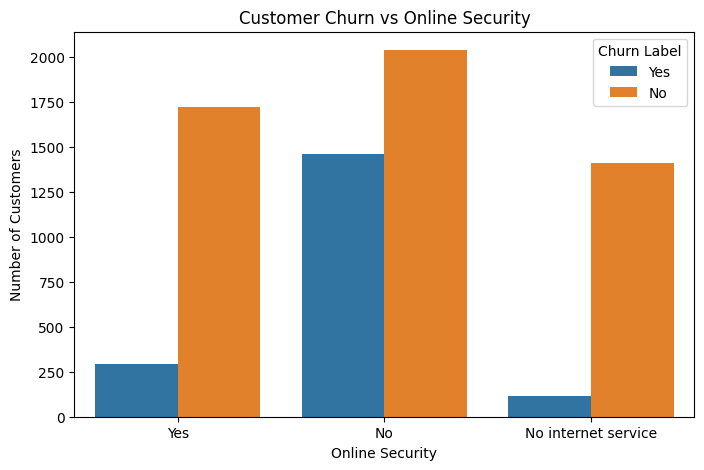

In [26]:
# Churn vs Online Security
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Online Security",
    hue="Churn Label"
)

plt.title("Customer Churn vs Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.show()

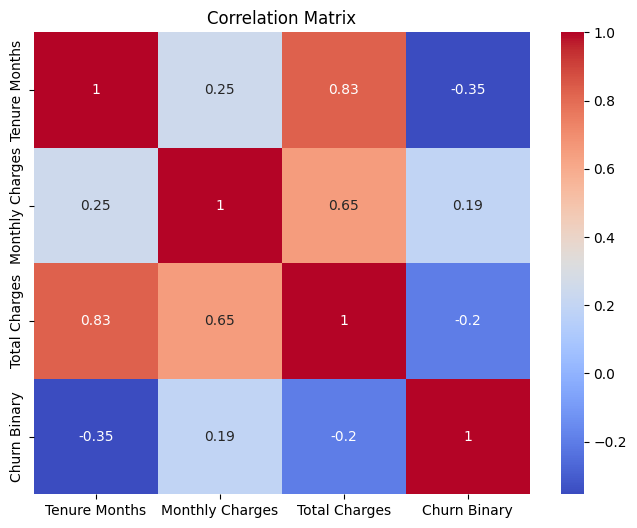

In [28]:
# Numerical Correlation
df_model["Churn Binary"] = (
    df_model["Churn Label"]
    .map({"Yes": 1, "No": 0})
)



numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Binary"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_model[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [29]:
df_model.drop(
    "Churn Binary",
    axis=1,
    inplace=True
)

In [30]:
# Preparing the Target Variable

df_model["Churn"] = (
    df_model["Churn Label"]
    .map({"Yes": 1, "No": 0})
)

df_model.drop(
    "Churn Label",
    axis=1,
    inplace=True
)

In [31]:
df_model["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [32]:
# Separating the Features and Target Variable

X = df_model.drop(
    "Churn",
    axis=1
)

y = df_model["Churn"]

In [33]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 19)
Target: (7032,)


In [34]:
# Converting categorical data
# As we know our data have many text columns and machine learning models need numerical values
# so for that we will be using one hot encoding

X = pd.get_dummies(
    X,
    drop_first=True
)

In [35]:
# Now check values
X.head()

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,False,False,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,False,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,False,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,True,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False


In [36]:
X.shape

(7032, 30)

In [37]:
# Now we are ready to train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [39]:
# Model 1: Logistic Regression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
y_pred_log = log_model.predict(
    X_test_scaled
)

y_prob_log = log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [41]:
# Evaluating the model
log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

log_precision = precision_score(
    y_test,
    y_pred_log
)

log_recall = recall_score(
    y_test,
    y_pred_log
)

log_f1 = f1_score(
    y_test,
    y_pred_log
)

log_auc = roc_auc_score(
    y_test,
    y_prob_log
)

print("Logistic Regression")
print("-------------------")
print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")
print(f"ROC-AUC  : {log_auc:.4f}")

Logistic Regression
-------------------
Accuracy : 0.7292
Precision: 0.4941
Recall   : 0.7861
F1 Score : 0.6068
ROC-AUC  : 0.8424


In [42]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [43]:
y_pred_rf = rf_model.predict(
    X_test
)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

In [44]:
# Evaluating the random forest model

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest")
print("-------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest
-------------
Accuracy : 0.7939
Precision: 0.6419
Recall   : 0.5080
F1 Score : 0.5672
ROC-AUC  : 0.8295


In [45]:
# Model 3 : XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

In [48]:
# Evaluating the XGBoost Model
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost")
print("-------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

XGBoost
-------
Accuracy : 0.7825
Precision: 0.6012
Recall   : 0.5401
F1 Score : 0.5690
ROC-AUC  : 0.8384


In [49]:
# Now finally we will compare all these 3 models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        log_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        log_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        log_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        log_auc,
        rf_auc,
        xgb_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.729211,0.494118,0.786096,0.606811,0.842392
1,Random Forest,0.793888,0.641892,0.508021,0.567164,0.829531
2,XGBoost,0.782516,0.601190,0.540107,0.569014,0.838422


In [50]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7292,0.4941,0.7861,0.6068,0.8424
1,Random Forest,0.7939,0.6419,0.5080,0.5672,0.8295
2,XGBoost,0.7825,0.6012,0.5401,0.5690,0.8384


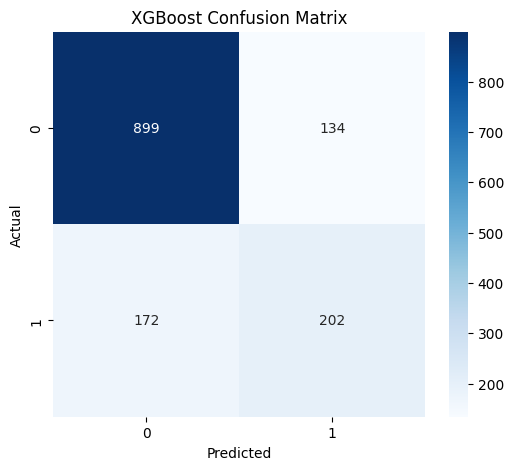

In [51]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.54      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [53]:
# ROC Curve
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_log
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

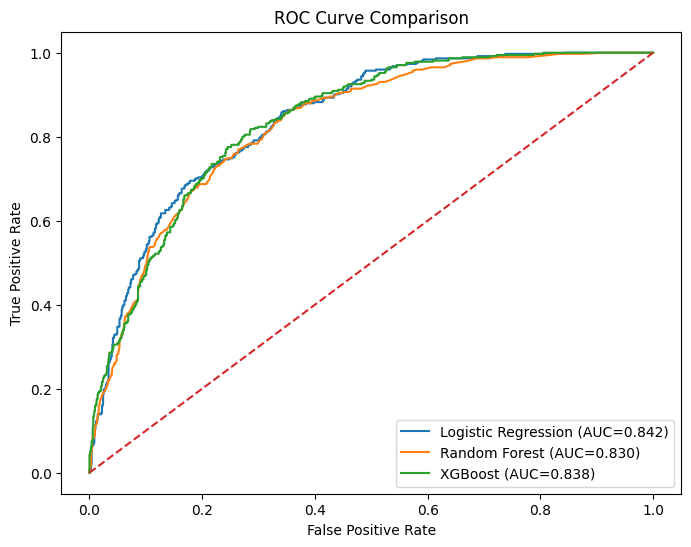

In [55]:
# Visualizing the ROC Curve for all the three models

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC={log_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={xgb_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [56]:
# Feature Importance
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

feature_importance = (
    feature_importance
    .sort_values(ascending=False)
)

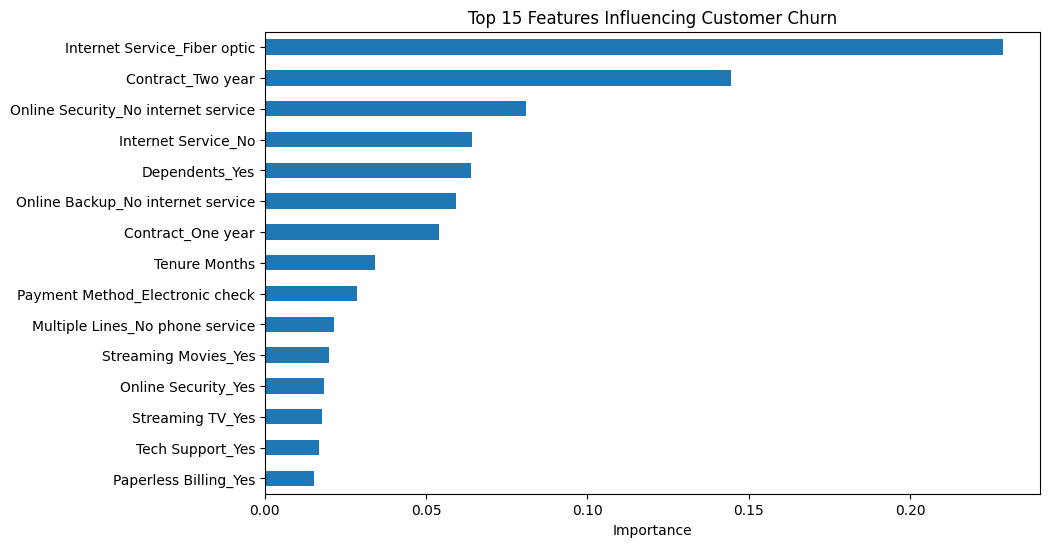

In [57]:
# Top features of our data

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Importance")

plt.show()

In [58]:
# Now According to all of this our best model is Logistic Regression
# So we will now save this model
joblib.dump(
    log_model,
    "churn_model.pkl"
)


['churn_model.pkl']

In [59]:
# Saving the Scalar
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [60]:
# Saving the features names
joblib.dump(
    X.columns.tolist(),
    "features.pkl"
)

['features.pkl']

In [61]:
# Lets verify that it actually works or not
# For that creating a Test Prediction

sample_customer = X_test.iloc[[0]]


prediction = xgb_model.predict(
    sample_customer
)[0]

probability = xgb_model.predict_proba(
    sample_customer
)[0][1]

In [62]:
print(
    "Prediction:",
    "Churn" if prediction == 1 else "No Churn"
)

print(
    f"Churn Probability: {probability * 100:.2f}%"
)

Prediction: No Churn
Churn Probability: 1.36%


In [63]:
# For identifying the risk level we will create a risk categories
# Creating Risk Categories
def risk_category(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"

In [64]:
risk = risk_category(
    probability
)

print("Risk Level:", risk)

Risk Level: Low Risk


In [65]:
# Now we can ADD one more thing which is Business recommendations

def recommendation(risk):

    if risk == "High Risk":
        return (
            "Offer a personalized discount, "
            "loyalty benefit, or long-term contract."
        )

    elif risk == "Medium Risk":
        return (
            "Send a personalized offer and "
            "improve customer engagement."
        )

    else:
        return (
            "Maintain service quality and "
            "provide loyalty rewards."
        )

In [66]:
print(
    "Recommendation:",
    recommendation(risk)
)

Recommendation: Maintain service quality and provide loyalty rewards.


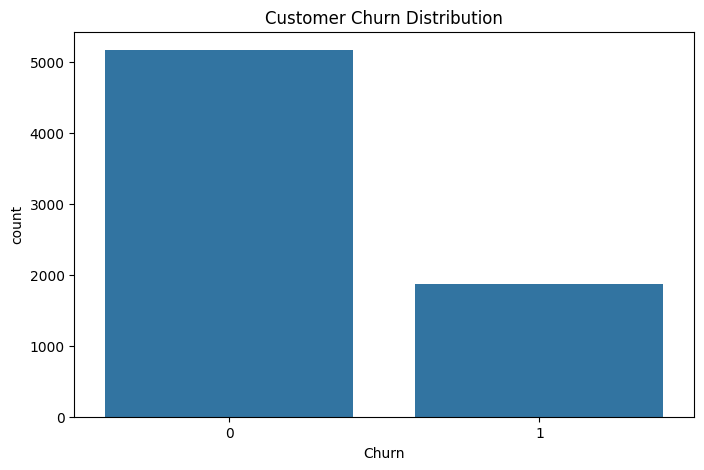

In [67]:
# Save the graph
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_model,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.savefig(
    "churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()